loaded: {'train': 9600, 'es': 3200, 'eval': 3200} | device: cuda
  TEACHER (config): tabpfn
  TEACHER (in use): tabpfn   device=cuda
  >> Real TabPFN teacher in use.
saved | mean pT (eval) = 0.0681 | actual default rate = 0.0819
[saved] 01_teacher_quality.csv
[saved] 01_teacher_reliability.png  &  01_teacher_reliability.pdf


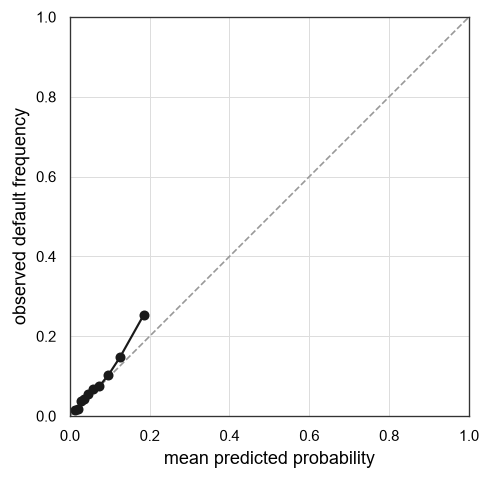

In [1]:
# Notebook 01 — Teacher TFM Inference & Calibration

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common as C
import config as CFG
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
meta = json.load(open(C.PROC_DIR / "meta.json"))
FEATURES = meta["features"]
part = lambda n: (X.iloc[SP[n]], y[SP[n]])
Xtr, ytr = part("train"); Xes, yes = part("es"); Xev, yev = part("eval")
print("loaded:", {k: len(v) for k, v in SP.items()}, "| device:", C.torch_device())


# ----------------------------------------------------------------------------
# Teacher fitting
# ----------------------------------------------------------------------------
def fit_teacher_tabpfn(Xtr, ytr):
    """Real TabPFN teacher (GPU when available). PREVALENCE-PRESERVING context to
    the row cap (keeps the teacher calibrated), batched scoring."""
    from tabpfn import TabPFNClassifier
    dev = C.torch_device()
    mp = getattr(CFG, "TABPFN_MODEL_PATH", None)
    clf = TabPFNClassifier(device=dev, random_state=C.RANDOM_STATE,
                           **({"model_path": mp} if mp else {}))
    cap = int(CFG.TEACHER_ROW_CAP)
    med = Xtr.median(numeric_only=True)
    if len(Xtr) > cap:                          # prevalence-preserving context
        from sklearn.model_selection import train_test_split
        take, _ = train_test_split(np.arange(len(Xtr)), train_size=cap,
                                   stratify=ytr, random_state=C.RANDOM_STATE)
        clf.fit(Xtr.iloc[take].fillna(med), ytr[take])
    else:
        clf.fit(Xtr.fillna(med), ytr)
    bs = int(CFG.TEACHER_PREDICT_BATCH)
    def pf(Z):
        Z = Z.fillna(med)
        out = np.empty(len(Z))
        for i in range(0, len(Z), bs):
            out[i:i+bs] = clf.predict_proba(Z.iloc[i:i+bs])[:, 1]
        return out
    return pf

def fit_teacher_proxy(Xtr, ytr, Xes, yes):
    from sklearn.ensemble import HistGradientBoostingClassifier
    from sklearn.isotonic import IsotonicRegression
    base = HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15,
        random_state=C.RANDOM_STATE)
    base.fit(Xtr, ytr)
    iso = IsotonicRegression(out_of_bounds="clip").fit(
        base.predict_proba(Xes)[:, 1], yes)
    return lambda Z: np.clip(iso.transform(base.predict_proba(Z)[:, 1]),
                             1e-6, 1 - 1e-6)

teacher_fn, used_kind = None, None
if CFG.TEACHER_KIND == "tabpfn":
    try:
        teacher_fn = fit_teacher_tabpfn(Xtr, ytr); used_kind = "tabpfn"
    except Exception as e:
        print(f"[TabPFN unavailable: {type(e).__name__}: {e}] -> proxy teacher")
if teacher_fn is None:
    if CFG.TEACHER_KIND == "tabpfn" and getattr(CFG, "STRICT_TEACHER", True):
        raise RuntimeError(
            "TEACHER_KIND='tabpfn' but TabPFN is unavailable and "
            "STRICT_TEACHER=True. Install tabpfn (+ CUDA torch) for a real TFM "
            "teacher, or set STRICT_TEACHER=False in config.py to allow the "
            "calibrated proxy teacher (demo/ablation only).")
    teacher_fn = fit_teacher_proxy(Xtr, ytr, Xes, yes); used_kind = "proxy"

# --- LOUD teacher banner ------------------------------------------------------
print("=" * 64)
print(f"  TEACHER (config): {CFG.TEACHER_KIND}")
print(f"  TEACHER (in use): {used_kind}   device={C.torch_device()}")
if used_kind == "proxy":
    print("  >> PROXY GBDT teacher — NOT a TabPFN/TFM result.")
else:
    print("  >> Real TabPFN teacher in use.")
print("=" * 64)


# ----------------------------------------------------------------------------
# Teacher probabilities on every split (p^T)
# ----------------------------------------------------------------------------
pT = {"train": teacher_fn(Xtr), "es": teacher_fn(Xes), "eval": teacher_fn(Xev)}
np.savez(C.PROC_DIR / "teacher_probs.npz", **pT)
json.dump({"kind": used_kind}, open(C.PROC_DIR / "teacher_meta.json", "w"))
print("saved | mean pT (eval) =", round(pT["eval"].mean(), 4),
      "| actual default rate =", round(yev.mean(), 4))


# ----------------------------------------------------------------------------
# Teacher quality on eval
# ----------------------------------------------------------------------------
p, yv = pT["eval"], yev
bm = C.brier_murphy(yv, p, n_bins=10)
teacher_tbl = pd.DataFrame([{
    "teacher": used_kind, "AUC": C.auc(yv, p), "ECE": C.ece(yv, p),
    "Brier": bm["brier"], "reliability": bm["reliability"],
    "refinement": bm["refinement"], "Spiegelhalter_Z": C.spiegelhalter_z(yv, p)["z"]}])
C.save_table(teacher_tbl.round(5), "01_teacher_quality")
teacher_tbl.round(4)


# ----------------------------------------------------------------------------
# Figure: teacher reliability diagram (grayscale), eval split
# ----------------------------------------------------------------------------
ids = C._bin_ids(p, 10, "quantile")
xs = np.array([p[ids == b].mean() for b in np.unique(ids)])
ys = np.array([yv[ids == b].mean() for b in np.unique(ids)])
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot([0, 1], [0, 1], color="#999999", linewidth=1.0, linestyle="--")
ax.plot(xs, ys, marker="o", color="#1a1a1a", linewidth=1.3, markersize=5)
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed default frequency")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
fig.tight_layout()
C.save_fig(fig, "01_teacher_reliability")
plt.show()